In [26]:
# Import libraries
import numpy as np
import pickle
import mne
import os
import ipywidgets as widgets
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline
# set size of raw browser
mne.utils.config.set_config('MNE_BROWSE_RAW_SIZE','16.0,8.0')

## Kig manuelt på ICA og fjern passende kompnenter


In [27]:
d_s1 = mne.io.read_raw_fif("/Users/johanandersen/Desktop/EM3/experiment-local/EEG-data/clean_final_data/part1_pink_noise_clean_raw.fif", preload=True)
d_s2 = mne.io.read_raw_fif("/Users/johanandersen/Desktop/EM3/experiment-local/EEG-data/clean_final_data/part3_BB_clean_raw.fif", preload=True)




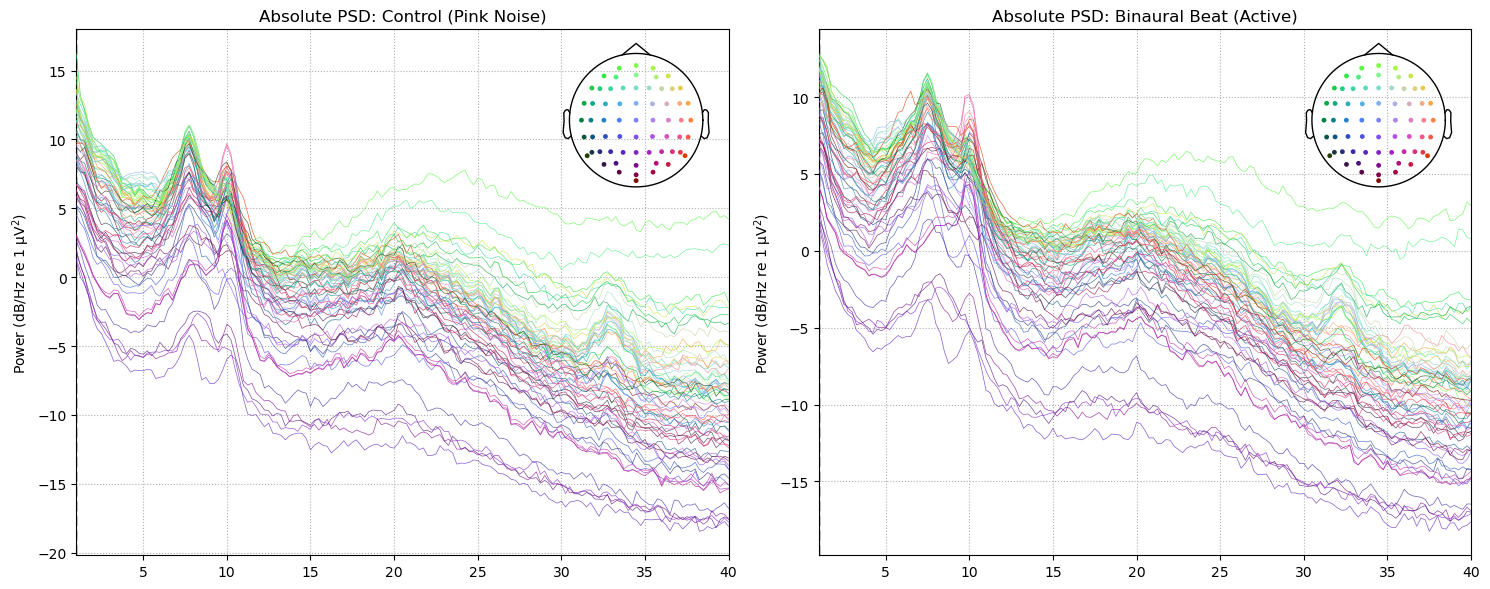

In [38]:
import matplotlib.pyplot as plt

# 1. Create a figure with 1 row and 2 columns
# figsize width=15, height=6 gives them plenty of room side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Control on the first axis (left)
obj1.plot(axes=ax1, show=False, spatial_colors=True)
ax1.set_title("Absolute PSD: Control (Pink Noise)")

# 3. Plot Binaural on the second axis (right)
obj2.plot(axes=ax2, show=False, spatial_colors=True)
ax2.set_title("Absolute PSD: Binaural Beat (Active)")

# 4. Clean up layout so labels don't overlap and show
plt.tight_layout()
plt.show()

In [40]:
import warnings
import mne

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

In [44]:

def power_analysis_comprehensive(d):
    # 1. Compute PSD (1-40 Hz)
    # n_fft=2048 provides good frequency resolution
    psd_obj = d.compute_psd(method='welch', fmin=1, fmax=40, n_fft=2048)
    psds, freqs = psd_obj.get_data(return_freqs=True)
    
    # 2. Find the index for 20 Hz
    idx_20hz = np.argmin(np.abs(freqs - 20))
    
    # --- ABSOLUTE POWER ---
    # Power at exactly 20Hz, averaged across all EEG channels
    # psds is (channels, frequencies) -> mean(axis=0) gives average channel
    abs_power_20hz = psds.mean(axis=0)[idx_20hz]
    
    # --- TOTAL POWER ---
    # Sum of power across all frequencies (1-40Hz) for the average channel
    # This represents the 'total energy' in the EEG signal
    total_power = psds.mean(axis=0).sum()
    
    # --- RELATIVE POWER ---
    # What percentage of the total energy is at 20Hz?
    rel_power_20hz = abs_power_20hz / total_power
    
    return {
        'psd_obj': psd_obj,
        'absolute': abs_power_20hz,
        'relative': rel_power_20hz,
        'total': total_power
    }

# Run the analysis for both conditions
res1 = power_analysis_comprehensive(d_s1) # Control
res2 = power_analysis_comprehensive(d_s2) # Binaural

print(f"CONTROL:   Abs: {res1['absolute']:.2e} | Rel: {res1['relative']:.4f}")
print(f"BINAURAL:  Abs: {res2['absolute']:.2e} | Rel: {res2['relative']:.4f}")

# Calculate the difference in Relative Power
rel_diff = res2['relative'] - res1['relative']
print(f"\nDifference in Relative Power: {rel_diff:.6f}")

CONTROL:   Abs: 1.11e-12 | Rel: 0.0024
BINAURAL:  Abs: 1.11e-12 | Rel: 0.0023

Difference in Relative Power: -0.000119


## What are our regions of interrest????


In [59]:
rois = {
    'Frontal': [
        'Fp1', 'AF3', 'AF7', 'F3', 'F5', 'F7',  # Left Frontal
        'Fp2', 'AF4', 'AF8', 'F4', 'F6', 'F8'   # Right Frontal
    ],
    'Auditory': [
        'FT7', 'T7', 'TP7', 'FC5', 'C5', 'CP5', # Left Auditory
        'FT8', 'T8', 'TP8', 'FC6', 'C6', 'CP6', # Right Auditory
        'Fz', 'FCz', 'Cz'                       # Midline Vertex
    ],
    'Occipital_Visual': ['O1', 'O2', 'Oz', 'PO3', 'PO4', 'POz', 'PO7', 'PO8'],

    "Gonzalez" : ["T7", "T8", "P8", "O2", "F8", "F7"],
    "CPP" : ['CPz', 'Pz', 'CP1', 'CP2']
}


In [46]:

# Run the analysis only on those channels
res1_ROI = power_analysis_comprehensive(d_s1.copy().pick(rois["Frontal"]))
res2_ROI = power_analysis_comprehensive(d_s2.copy().pick(rois["Frontal"]))

print(f"CONTROL:   Abs: {res1_ROI['absolute']:.2e} | Rel: {res1_ROI['relative']:.4f}")
print(f"BINAURAL:  Abs: {res2_ROI['absolute']:.2e} | Rel: {res2_ROI['relative']:.4f}")

# Calculate the difference in Relative Power
rel_diff = res2_ROI['relative'] - res1_ROI['relative']
print(f"\nDifference in Relative Power: {rel_diff:.6f}")

CONTROL:   Abs: 2.14e-12 | Rel: 0.0028
BINAURAL:  Abs: 1.88e-12 | Rel: 0.0025

Difference in Relative Power: -0.000336


## Are there diffrences in the power plots??

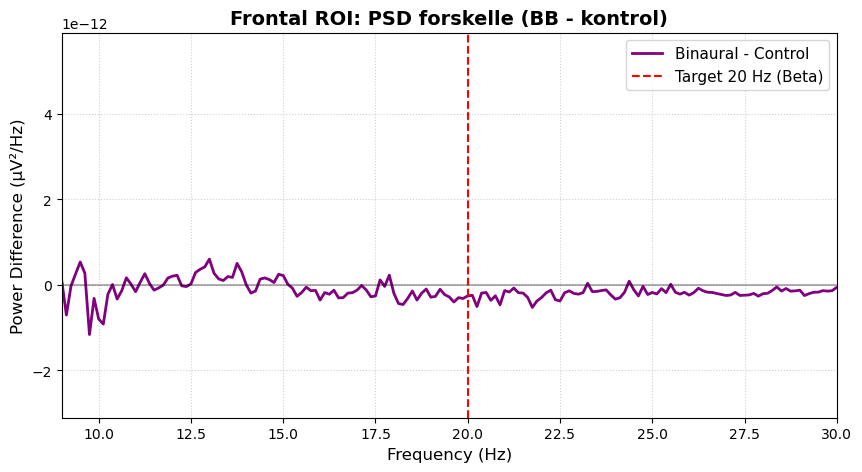

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute the underlying PSD objects for the chosen ROI (e.g., Frontal)
# We pick the channels and calculate the spectrum up to 50 Hz
psd_control_obj  = d_s1.copy().pick(rois["Frontal"]).compute_psd(fmin=1, fmax=50, method='welch')
psd_binaural_obj = d_s2.copy().pick(rois["Frontal"]).compute_psd(fmin=1, fmax=50, method='welch')

# 2. Extract the actual data matrices and the shared frequency scale
# get_data() returns: (data_matrix, frequencies)
psds_control, freqs  = psd_control_obj.get_data(return_freqs=True)
psds_binaural, _     = psd_binaural_obj.get_data(return_freqs=True)

# 3. Calculate the mean power across all channels in this ROI
mean_psd_control  = psds_control.mean(axis=0)
mean_psd_binaural = psds_binaural.mean(axis=0)

# 4. Calculate the Difference (Binaural stimulation minus Control baseline)
psd_diff = mean_psd_binaural - mean_psd_control

# 5. Plotting
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the continuous difference curve
ax.plot(freqs, psd_diff, color='purple', linewidth=2, label='Binaural - Control')

# Add a flat reference line at zero (where positive means entrainment)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)

# Highlight your 20 Hz Target frequency
ax.axvline(20, color='red', linestyle='--', linewidth=1.5, label='Target 20 Hz (Beta)')

# Formatting the visual canvas
ax.set_title("Frontal ROI: PSD forskelle (BB - kontrol)", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Power Difference (µV²/Hz)", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=11)

# Zoom in tightly on the Beta frequency band of interest
ax.set_xlim(9, 30) 

plt.show()

## What about a more local ROI (jeg ved ikke hvilke endnu, det skal vi tale om)

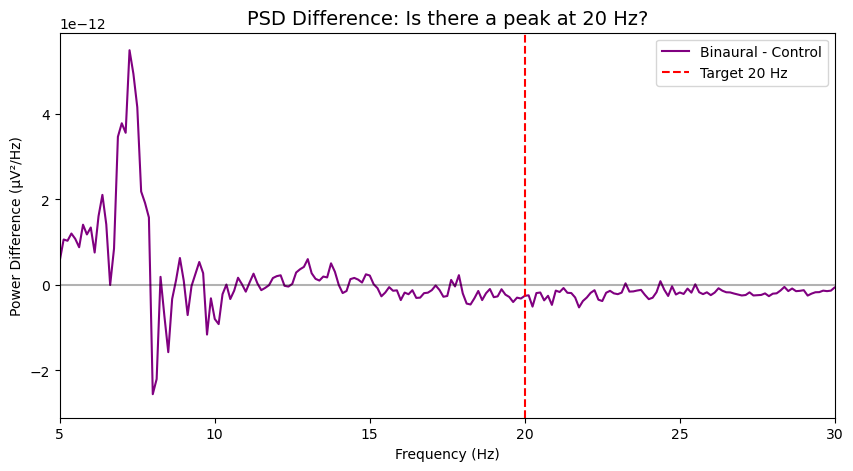

In [62]:
obj1 = res1_ROI["psd_obj"]
obj2 = res2_ROI["psd_obj"]



psds1, freqs = obj1.get_data(return_freqs=True) # Control
psds2, _     = obj2.get_data(return_freqs=True) # Binaural

# 2. Calculate the mean across all channels
mean_psd1 = psds1.mean(axis=0)
mean_psd2 = psds2.mean(axis=0)

# 3. Calculate the Difference (Binaural - Control)
psd_diff = mean_psd2 - mean_psd1

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the difference line
ax.plot(freqs, psd_diff, color='purple', label='Binaural - Control')

# Add a reference line at zero
ax.axhline(0, color='black', linestyle='-', alpha=0.3)

# Highlight the 20 Hz Target
ax.axvline(20, color='red', linestyle='--', label='Target 20 Hz')

# Formatting
ax.set_title("PSD Difference: Is there a peak at 20 Hz?", fontsize=14)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Difference (µV²/Hz)")
ax.legend()

# OPTIONAL: Zoom in on the area of interest
ax.set_xlim(5, 30) 

plt.show()

In [17]:
g1_Park = ["AF7", "AF8", "TP7", "TP8"]
g2_Gonzalez = ["T7", "T8", "P8", "O2", "F8", "F7"]

In [60]:
import pandas as pd
import numpy as np

# 1. Define your Regions of Interest (ROIs)

def extract_roi_power(clean_raw, participant_id, condition_name):
    sfreq = clean_raw.info['sfreq']
    segment_duration = 20.0  # 20-second windows
    total_duration = clean_raw.times[-1]
    n_segments = int(total_duration // segment_duration)
    
    rows = []
    
    for seg in range(n_segments):
        tmin = seg * segment_duration
        tmax = tmin + segment_duration
        
        # Crop out this 20-second slice of data
        seg_data = clean_raw.copy().crop(tmin=tmin, tmax=tmax, verbose=False)
        
        # Compute PSD
        psd_obj = seg_data.compute_psd(method='welch', fmin=18, fmax=22, n_fft=1024, verbose=False)
        psds, freqs = psd_obj.get_data(return_freqs=True)
        idx_20hz = np.argmin(np.abs(freqs - 20))
        
        # --- FIXED: CALCULATE THE GLOBAL BASELINE ---
        # Since psds ONLY contains valid brain channels now, we can safely average 
        # across all its rows without manually filtering out 'Status' or 'bads'
        global_20hz_power = psds[:, idx_20hz].mean()
        
        # Extract power for each ROI
        for roi_name, channels in rois.items():
            # FIXED: Find indices relative to the psd_obj channel order
            ch_indices = [psd_obj.ch_names.index(ch) for ch in channels if ch in psd_obj.ch_names]
            
            if ch_indices:
                # 1. Absolute power
                roi_abs_power = psds[ch_indices, idx_20hz].mean()
                
                # 2. Relative power (Normalized by the global baseline)
                roi_relative_power = roi_abs_power / global_20hz_power
                
                rows.append({
                    'Participant': participant_id,
                    'Condition': condition_name,
                    'Segment_ID': seg + 1,  # Tracks the chronological timeline chunks
                    'ROI': roi_name,
                    'abs_power': roi_abs_power,
                    'relative_power': roi_relative_power  
                })
            
    return pd.DataFrame(rows)

# Run the updated pipeline
df_cond1 = extract_roi_power(d_s1, participant_id='VJJ', condition_name='Binaural')
df_cond2 = extract_roi_power(d_s2, participant_id='VJJ', condition_name='Control')
data_long = pd.concat([df_cond1, df_cond2], ignore_index=True)





In [61]:
data_long.to_csv("eeg_psd_new.csv", index=False)